# Task 3: Exploratory Data Analysis (EDA) on Netflix Dataset

**Internship Project**

Identify trends and patterns in Netflix content using Exploratory Data Analysis (EDA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

In [16]:
print("----------Load Dataset---------")
df = pd.read_csv('netflix_titles.csv')
df.head()

----------Load Dataset---------


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [19]:
print("--------------- Dataset Overview--------------")
print('\n Shape:', df.shape)
df.info()

--------------- Dataset Overview--------------

 Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [20]:
print("-------------------Missing Values Analysis-----------------")
df.isnull().sum()

-------------------Missing Values Analysis-----------------


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [5]:
df.fillna('Unknown', inplace=True)

In [21]:
print("---------------------Summary Statistics-------------------")
df.describe(include='all').T

---------------------Summary Statistics-------------------


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


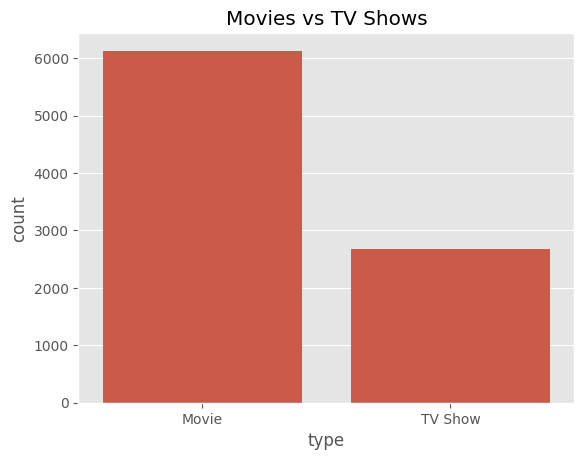

In [7]:
print("-----------------------Movies vs TV Shows---------------")
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows')
plt.show()

------------------------Content Added Over Time------------- 



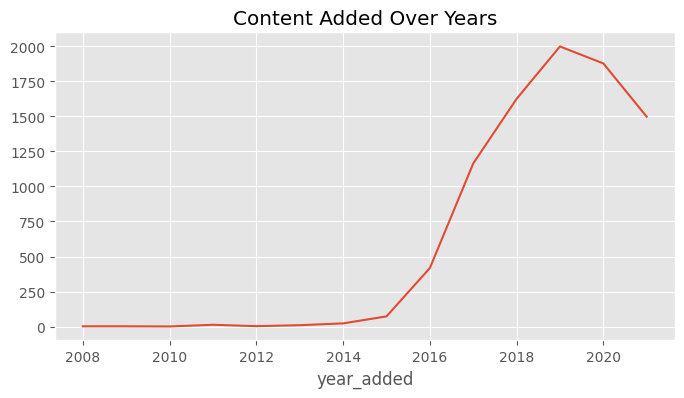

In [22]:
print("------------------------Content Added Over Time------------- \n")
df['date_added']=pd.to_datetime(df['date_added'], errors='coerce')
df['year_added']=df['date_added'].dt.year

df['year_added'].value_counts().sort_index().plot(kind='line', figsize=(8,4))
plt.title('Content Added Over Years')
plt.show()

--------------------Release Year Trend----------------- 



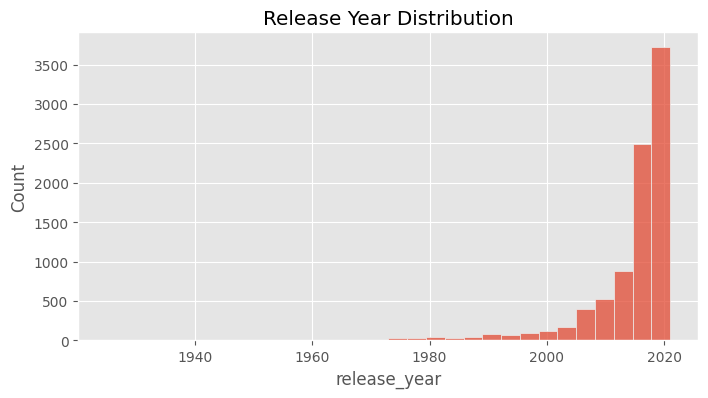

In [23]:
print("--------------------Release Year Trend----------------- \n")
plt.figure(figsize=(8,4))
sns.histplot(df['release_year'], bins=30)
plt.title('Release Year Distribution')
plt.show()

---------------Top Content Producing Countries-------------- 



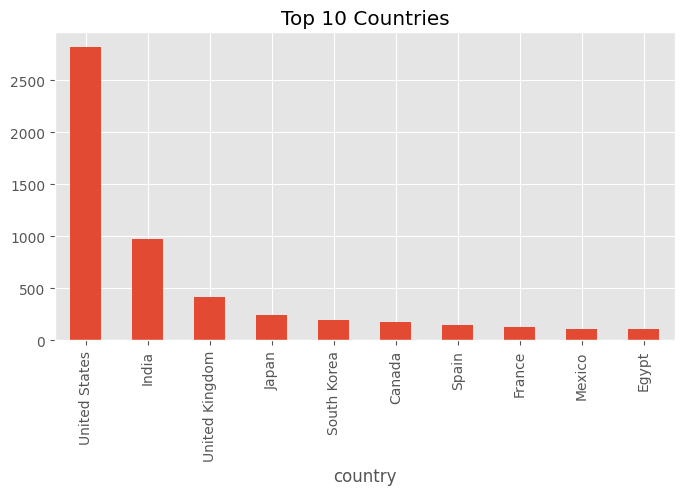

In [24]:
print("---------------Top Content Producing Countries-------------- \n")
df['country'].value_counts().head(10).plot(kind='bar', figsize=(8,4))
plt.title('Top 10 Countries')
plt.show()

------------------------Ratings Distribution----------------- 



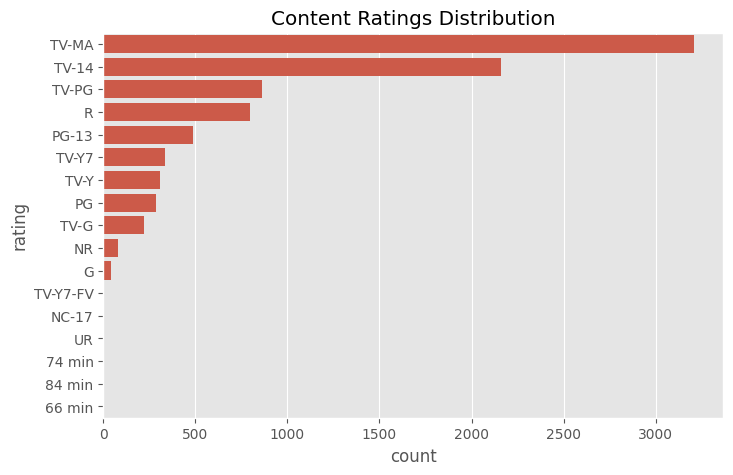

In [25]:
print("------------------------Ratings Distribution----------------- \n")
plt.figure(figsize=(8,5))
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title('Content Ratings Distribution')
plt.show()

-----------------------Top Genres------------------ 



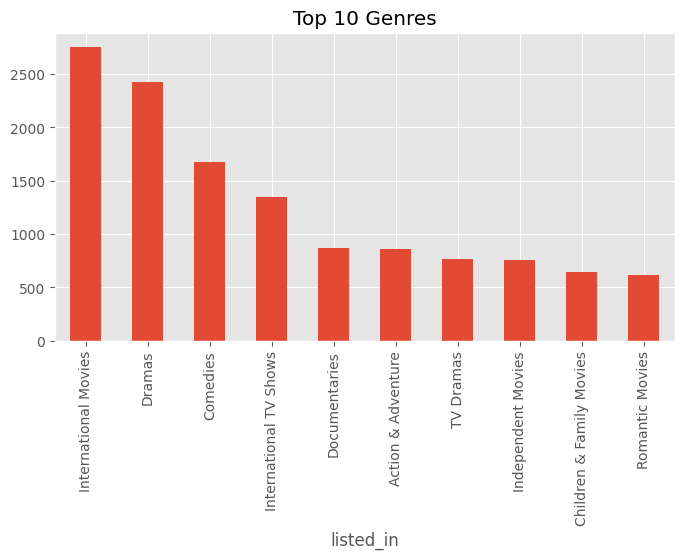

In [26]:
print("-----------------------Top Genres------------------ \n")
genres=df['listed_in'].str.split(', ').explode()
genres.value_counts().head(10).plot(kind='bar', figsize=(8,4))
plt.title('Top 10 Genres')
plt.show()

----------------Movie Duration Analysis-------------- 



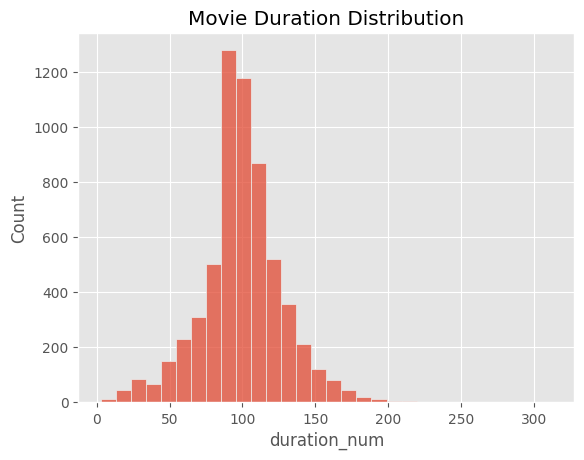

In [27]:
print("----------------Movie Duration Analysis-------------- \n")
movies=df[df['type']=='Movie'].copy()
movies['duration_num']=movies['duration'].str.extract(r'(\d+)').astype(float)
sns.histplot(movies['duration_num'], bins=30)
plt.title('Movie Duration Distribution')
plt.show()

---------------Correlation Analysis----------------- 



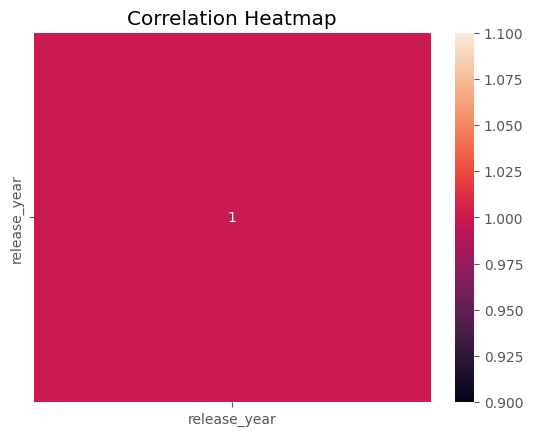

In [28]:
print("---------------Correlation Analysis----------------- \n")
corr=df[['release_year']].corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

## 13. Key Findings

1. Movies dominate Netflix content.
2. Content additions increased significantly after 2015.
3. USA is the largest content-producing country.
4. Drama and Comedy are among the most popular genres.
5. Most movies have a duration between 80 and 120 minutes.
6. Most content is targeted toward mature audiences.
7. Netflix focuses heavily on modern content released after 2000.


## 14. Conclusion

This EDA project explored Netflix's content library and identified important trends related to content type, release years, countries, genres, ratings, and durations. The analysis provides useful insights into Netflix's content strategy and audience preferences.
